# Methoden en Technieken 2025-2026 -- Blok 3

## Datapunt Opdracht 3a

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en technische requirements** op.
- B2: Je **stelt op basis van requirements** en data **een geschikte architectuur voor een AI-oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld** **machine learning**, **deep learning**, kennisrepresentatie, computer vision en natural language processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability, explainability, **model complexity** en resource demand.
(Leeruitkomst B1 is voor deze opdracht niet van toepassing.)

![](https://gymnasium.farama.org/_images/acrobot.gif)

## De opdracht

Het doel van deze opdracht is om een reinforcement learning model te maken dat het spel AcroBot speelt. Hier wil je een dubbele pendulum zo duwen dat het zo snel mogelijk een bepaalde hoogte bereikt.

Voor meer informatie over acties, belongingen, etc, zie [https://gymnasium.farama.org/environments/classic_control/acrobot/](https://gymnasium.farama.org/environments/classic_control/acrobot/).

- Stel een korte lijst van *requirements* op en verantwoord deze
- Kies een model en verantwoord je keuze
- Indien nodig, voer enkele (max 2) iteraties een verbeteringen uit, verantwoord je keuzes
- Evalueer je model (indien je .gif bestanden aanmaakt van gespeelde spellen, zoals in de code in de lessen, lever deze .gif bestanden ook in samen met dit notebook)
- Houd je antwoorden kort en bondig



De volgende code laad deze *environment* in.

In [2]:
import gymnasium

env = gymnasium.make("Acrobot-v1", render_mode="rgb_array_list")

---
<h1 style="text-align: center;">Kaan Gogcay - M&T Opdracht 3b</h1>

---

Notebook Structuur
- Requirements (A2)
- Baseline Model (C2)
- RL Algoritme Keuze (B2)
- Modelleren in Iteraties (B3)
    - Iteratie 1 (B3, C2)
    - Iteratie 2 (B3, C2)

# Requirements (A2)
De opdracht is erg beknopt en duidelijk geformuleerd. De enige requirements die ik er uit kan halen zijn de volgende:

- RQ1. Opdracht moet ingeleverd worden op 10 April 2026
- RQ2. Een baseline model opstellen
- RQ3. Een weloverwogen keuze maken voor het RL algoritme dat ik ga gebruiken
- RQ4. Een RL model maken dat de pendulum sneller omhoog krijgt dan het baseline model

# Baseline model (C2)
## Nulmodel
Bij het opstellen van een baseline model ga ik eerst proberen om een nulmodel te bouwen. Dit kan ik doen door een model te maken dat elke tijdstap dezelfde actie uitvoert. De action space bevat 3 acties [0, 1, 2]. Voor het nulmodel gaan we proberen om elke tijdstap actie 0 uit te voeren.

In [3]:
# Nulmodel altijd 0 (-1 torque)
env = gymnasium.make("Acrobot-v1", render_mode="human") # want ik wil zien wat er gebeurt

episodes = 1
episode_summary = []

for e in range(episodes):
    observation, info = env.reset()
    steps = 0

    while True:
        action = 0  # torque -1
        observation, reward, terminated, truncated, info = env.step(action)
        steps += 1

        if terminated or truncated:
            break

    episode_summary.append((steps, reward))
print(f"Steps taken in episodes: {episode_summary}")

Steps taken in episodes: [(500, -1.0)]


Altijd een kant op bewegen krijgt de pendulum niet omhoog. Hetzelfde kun je proberen voor acties `1` en `2`. Maar 1 doet niks en 2 draait de andere kant op dus is het logisch dat het herhalen van dezelfde actie voor de gehele episode het spel nooit zal kunnen uitspelen. Er is dus een geavanceerdere baseline model nodig.

## Random Agent

Typisch (in simpele) RL problemen is het niet een gek idee om een random agent te gebruiken als baseline. Ook docent Robert gaf aan dat het een goed idee is om een random agent te gebruiken als basseline. Dit is (normaal gesproken) een goed idee want, stel dat je model beter presteert dan de random agent, dan kun je dus concluderen dat je model geen random acties neemt en dus "nadenkt" over de acties die hij neemt. Nu is het probleem in dit gegeven scenario dat het zo kan zijn dat een random agent het spel niet eens kan uitspelen, omdat dit spel meerdere "correcte" opeenvolgende acties vereist, waardoor de kans dat dit gebeurt te klein kan zijn.

Ik ga proberen om het spel uit te spelen met een random agent. Mocht dit niet lukken kan ik eventueel naar een alternatief zoeken.

In [4]:
# Random Agent 
env = gymnasium.make("Acrobot-v1", render_mode="rgb_array_list") # want ik wil zien wat er gebeurt

episodes = 100
episode_summary = [] # list met tuples -> (aantal steps, reward)
episode_action_history = [] # list met actions
all_action_history = [] # lijst van list met actions

for e in range(episodes):
    observation, info = env.reset(seed=e) # reproducability
    steps = 0
    episode_action_history = []

    while True:
        action = env.action_space.sample()  # Take a random action
        observation, reward, terminated, truncated, info = env.step(action)
        steps += 1
        episode_action_history.append(action)

        if terminated or truncated: # truncated in v1 is max 500 steps
            break
    
    all_action_history.append(episode_action_history)
    episode_summary.append((steps, reward))
print(f"Steps taken in episodes: {episode_summary}")

Steps taken in episodes: [(500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (500, -1.0), (364, 0.0), 

Resultaten omzetten in dataframe en visualiseren

In [7]:
import pandas as pd

df = pd.DataFrame(episode_summary, columns=['steps', 'reward'])
df['episode'] = df.index + 1
df_sorted = df.sort_values(by='steps', ascending=True)

df_sorted.head

<bound method NDFrame.head of     steps  reward  episode
74    364     0.0       75
0     500    -1.0        1
2     500    -1.0        3
1     500    -1.0        2
4     500    -1.0        5
..    ...     ...      ...
95    500    -1.0       96
96    500    -1.0       97
97    500    -1.0       98
98    500    -1.0       99
99    500    -1.0      100

[100 rows x 3 columns]>

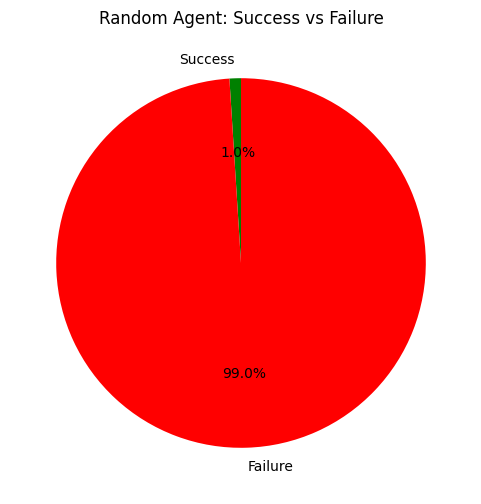

In [8]:
import matplotlib.pyplot as plt

# count successes and failures directly
success_count = sum(reward >= 0 for _, reward in episode_summary)
failure_count = sum(reward < 0 for _, reward in episode_summary)

# prepare data
counts = [success_count, failure_count]
labels = ['Success', 'Failure']
colors = ['green', 'red']

# plot pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Random Agent: Success vs Failure")
plt.show()


we zien dat de succesrate met een max van 500 stappen maar 1% is. We kunnen als baseline gebruiken dat het model een succesrate van 1% moet overtreffen bij het spelen van 100 episodes. Maar dan moet ik telkens 100 episodes spelen om mijn model te vergelijken met de baseline. Daarom ga ik proberen om een gemiddelde aantal benodigde stappen op te zoeken per episode. Dit is mogelijk door het ingebouwde limiet van 500 stappen te negeren en de random agent door te laten spelen tot hij het spelletje uitspeelt.

In [3]:
# Random Agent 
episodes = 100 # stuk minder episodes want anders gaat het veel te lang duren
episode_summary = [] # list met tuples -> (aantal steps, reward)
episode_action_history = [] # list met actions
all_action_history = [] # lijst van list met actions

for e in range(episodes):
    observation, info = env.reset(seed=e) # reproducability
    steps = 0
    episode_action_history = []

    while True:
        action = env.action_space.sample()  # Take a random action
        observation, reward, terminated, truncated, info = env.step(action)
        steps += 1
        episode_action_history.append(action)

        if terminated: # truncated in v1 is max 500 steps
            break
    
    all_action_history.append(episode_action_history)
    episode_summary.append((steps, reward))
print(f"Steps taken in episodes: {episode_summary}")

Steps taken in episodes: [(1783, 0.0), (4263, 0.0), (1156, 0.0), (3922, 0.0), (819, 0.0), (2074, 0.0), (4130, 0.0), (3650, 0.0), (2250, 0.0), (830, 0.0), (811, 0.0), (1594, 0.0), (3415, 0.0), (2506, 0.0), (899, 0.0), (1407, 0.0), (1426, 0.0), (2101, 0.0), (816, 0.0), (3854, 0.0), (4502, 0.0), (1236, 0.0), (3057, 0.0), (673, 0.0), (1108, 0.0), (1575, 0.0), (923, 0.0), (731, 0.0), (1070, 0.0), (1952, 0.0), (1305, 0.0), (2380, 0.0), (1831, 0.0), (4651, 0.0), (1085, 0.0), (988, 0.0), (3201, 0.0), (3542, 0.0), (1928, 0.0), (3841, 0.0), (1365, 0.0), (1503, 0.0), (2058, 0.0), (1260, 0.0), (2034, 0.0), (1574, 0.0), (567, 0.0), (1184, 0.0), (4138, 0.0), (425, 0.0), (2799, 0.0), (2897, 0.0), (2696, 0.0), (695, 0.0), (1158, 0.0), (3804, 0.0), (2014, 0.0), (631, 0.0), (1382, 0.0), (1176, 0.0), (1557, 0.0), (3890, 0.0), (1024, 0.0), (1726, 0.0), (1502, 0.0), (1327, 0.0), (1010, 0.0), (1254, 0.0), (2648, 0.0), (6717, 0.0), (2505, 0.0), (1225, 0.0), (891, 0.0), (3000, 0.0), (3271, 0.0), (1578, 0.0), 

In [4]:
import pandas as pd

df2 = pd.DataFrame(episode_summary, columns=['steps', 'reward'])
df2['episode'] = df2.index + 1
df2_sorted = df2.sort_values(by='steps', ascending=True)

avg_steps = df2['steps'].mean()
print(f"Average steps taken: {avg_steps}")

Average steps taken: 2015.3


Dus bij het spelen van 100 episodes zonder step limiet is het gemiddelde benodigde steps ongeveer 2015. Dit kan ik dus als maatstaf gebruiken voor mijn RL model, mijn RL model moet het spelletje sneller oplossen dan in 2015 stappen om de random agent te overtreffen.

## Additionele Succes Maatstaf
We hebben uit het kleine onderzoek geconcludeerd dat mijn model het spel moet oplossen binnen 2015 stappen om het baseline model te overtreffen. Nu lees ik op de gymnasium documentation dat dit reinforcement learning probleem een reward threshold heeft van -100. Dat betekent dat als het model per episode het spel uitspeelt met een reward van -100 of meer (dichter bij de nul, dus -100 - 0). Dan wordt het model gezien als een succes. Daarom lijkt me het nog een interessanter doel om het spel in 100 stappen of minder uit te spelen aangezien dat moeilijker zou moeten zijn. Dit zou dan ook eventueel mijn vijfde requirement kunnen zijn

- RQ5. Het model moet het spel uitspelen in 100 stappen of minder.

# RL Algoritme Keuze (B2)
> Om deze vraag te beantwoorden moeten we toch echt eerst kijken naar Chaos Theorie. Nee grapje (haha)

Om deze vraag te beantwoorden ga ik de voor- en nadelen bespreken van alle RL modellen die zijn besproken/getoond in de RL-lessen. Voordat we de algoritmes gaan bespreken is het handig om de environment eerst duidelijk in kaart te brengen.
- Action space van 3 discrete getallen [0, 1, 2]
- Observation Space van 6 dimensies met continue waarden (min: [ -1. -1. -1. -1. -12.566371 -28.274334], max: [  1.  1.  1.  1.  12.566371  28.274334])
- het doel van het spel: *"The goal is to apply torques on the actuated joint to swing the free end of the linear chain above a given height while starting from the initial state of hanging downwards."* Dus de onderste pendulum op een bepaalde ingestelde hoogte krijgen.
- elke step dat de agent het spel niet behaalt returnt de env een reward van -1. als de agent het spel behaalt krijgt die een reward van 0. 
- deterministisch probleem. Actie x in state y zal altijd resulteren in state z.

In de les is er een merkwaardig figuur getoond. Zie de figuur hieronder

<img src="https://spinningup.openai.com/en/latest/_images/rl_algorithms_9_15.svg" style="background-color: white; padding: 10px;">


> info in dit markdown blok is gebasseerd op: https://spinningup.openai.com/en/latest/spinningup/rl_intro2.html

Om te uit te zoeken wat de meest geschikte algoritme is voor het gegeven scenario ga ik proberen de flow van de tree volgen. De eerste vraag is dan: model free? of model based?

## Model-Free of Model-Based?
Een model-free agent leert geen expliciet model van de environment (De agent kan dus niet vantevoren berekenen dat actie x in state y resulteert in state z), Maar leert direct een policy of een action-value-functie op basis van ervaring. Model-based agents maken wel gebruikt van een model van de environment en gebruiken dit om vooruit te plannen [13].

In het geval van de environment gegeven env "acrobot" is het doel om een bepaalde 'winning' state te bereieken in een collectie van winning states. Dit probleem zou kunnen opgelost worden door trial en error, zonder dat het noodzakelijk is om de onderliggende logica van de environment te modelleren. Daarom kies ik voor nu om te focussen op model-free algoritmes, omdat model-based modellen voor dit gegeven probleem waarschijnlijk te overkill zijn en extra complexiteit toevoegt (het modelleren van een model dat de enviornment van acrobot kan voorspellen). (al zou je een model-based agent kunnen bouwen aangezien de environment deterministisch is en gebasseerd is op natuurkunde kun je vooruitkijken en uitrekenen wat de beste stappen zijn die je naar een winning state brengen maar dit lijkt me niet perse nodig omdat het probleem al zo simpel is). Zo filter ik 5 algoritmes weg (World Models, I2A, MBMF, MBVE, AlphaZero). Mocht blijken dat model-free methodes niet de baseline overtreffen, dan kan ik in een latere iteratie alsnog overwegen om model-based algoritmes te gebruiken.

## Action Space
We hebben nu nog 11 algoritmes over. VPG, A2C/A3C, PPO, TRPO, DDPG, TD3, SAC, DQN, C51, QR-DQN, HER. Nu zijn de algoritmes DDPG, TD3 en SAC ontworpen voor continue action spaces, in dit environment hebben we te maken met een discrete action space dus vallen deze 3 algortimes, DDPG, TD3 en SAC, ook af. HER is geen algoritme dus die schrijf ik ook af.

| Algoritme | Action Space | policy | Technisch Geschikt |
|-|-|-|-|
| Policy Gradient (VPG) | Both [5] | on | Ja |
| A2C / A3C | Both [12] | on [4] | Ja |
| PPO | Both [7] | on [4][7] | Ja |
| TRPO | Both [6] | on [4][6] | Ja | 
| DDPG | Continous [1] | off [4] | Nee |
| TD3 | Continous [2] | off [4] | Nee |
| SAC | Continous [3] | off [4] | Nee |
| DQN | Discrete [8] | off [4] | Ja |
| C51 | Discrete [9][11] | off [11] | Ja |
| QR-DQN | Discrete [10] | off [4] | Ja |
| HER | - | - | - |



## Policy Optimization of Q-Learning?
Kijken we naar de algortime tree is de volgende vraag: Wil ik policy optimization of q-learning toepassen? Ik kon niet perse veel vinden over deze vergelijking. Maar aangezien de policy optimization algoritmes allemaal on-policy zijn en de q-learning algoritmes off-policy, ga ik kijken naar de vergelijking on-policy vs off-policy. Hier heb ik een interessante video over gekeken die ik later ook als bron citeer.

## On-Policy of Off-Policy?
Het verschil tussen on- en off-policy is dat bij off-policy de behavioural policy en de target policy van elkaar gescheiden kunnen worden, terwijl ze bij on-policy identiek zijn [14]. Hierdoor vereisen on-policy methodes dat trainingsdata altijd verzameld wordt onder de huidige policy, waardoor experience replay theoretisch incompatible is. Experience replay is waardevol voor Acrobot omdat de omgeving veel episodes vereist voordat een goede policy ontstaat, dit baseer ik op het feit dat de gemiddelde step lengte voor completion 2015 steps is met mijn baseline. Door historische data te hergebruiken wordt het aantal benodigde environment interactions dusdanig verminderd. Om deze reden vallen VPG, A2C/A3C, PPO en TRPO af, en blijven DQN, C51 en QR-DQN over. voor de duidelijkheid, Ik geloof zeker dat on-policy kan werken in deze env, maar kies bewust voor off-policy wegens training efficiency. 

## DQN, C51 of QR-DQN?
DQN is het simpelste algoritme. C51 voegt wat complexiteit toe en QR-DQN voegt daar bovenop nog meer complexiteit toe. Maar dan is de vraag, is deze extra complexiteit die C51 en QR-DQN bieden waardevol? Als we kijken naar de cleanrl docs over C51 lezen we het volgende "C51 introduces a distributional perspective for DQN: instead of learning a single value for an action, C51 learns to predict a distribution of values for the action. Empirically, C51 demonstrates impressive performance in ALE." [9]. Distributions kunnen interessant zijn in stochastic environments omdat daar verdelingen van toepassing zijn. Stel we gebruiken C51 in een stochastic env, en we nemen een actie x in state y dan maakt C51 een verdeling van de verschillende states waar we in terrecht kunnen komen, bijvoorbeeld 46% state a, 2% state b en 52% state c. Maar in de deterministische environment, Acrobot, is dit redundant. Zo zal actie x in state y altijd in dezelfde state resulteren, dus zal C51 een overbodige distribute maken van 100% op state z bij wijze van. Dit maakt het gebruik van C51 dus overbodig in dit gegeven scenario, omdat het dan altijd 100% verdelingen zou maken. Dit concept dat ik heb uitgelegd is ook de reden waarom QR-DQN overbodig is aangezien het ook met distributions werkt [15]. Zo vallen C51 en QR-DQN af en blijft er nog maar één algoritme over en dat is DQN, dus ga ik DQN gebruiken voor deze opdracht.

**Bronnen**
- 1. (DDPG Paper) Continuous control with deep reinforcement learning https://arxiv.org/pdf/1509.02971
- 2. (TD3 Paper) Addressing Function Approximation Error in Actor-Critic Methods https://arxiv.org/pdf/1802.09477
- 3. (SAC Paper) Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor 
- 4. How to Choose a Reinforcement-Learning Algorithm https://arxiv.org/pdf/2407.20917
- 5. Vanilla Policy Gradient - OpenAI Spinning Up https://spinningup.openai.com/en/latest/algorithms/vpg.html#quick-facts
- 6. Trust Region Policy Optimization - OpenAI Spinning Up https://spinningup.openai.com/en/latest/algorithms/trpo.html
- 7. Proximal Policy Optimization - OpenAI Spinning Up https://spinningup.openai.com/en/latest/algorithms/ppo.html#quick-facts
- 8. DQN discrete action space - https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html#module-stable_baselines3.dqn
- 9. C51 Clean RL Docs https://docs.cleanrl.dev/rl-algorithms/c51/
- 10. QR-DQN https://www.emergentmind.com/topics/quantile-regression-deep-q-network-qr-dqn
- 11. C51 DI Engine Docs https://di-engine-docs.readthedocs.io/en/latest/12_policies/c51.html
- 12. A2C is almost exactly the same as PPO https://medium.com/analytics-vidhya/beating-pong-using-reinforcement-learning-part-2-a2c-and-ppo-b83391dd3657
- 13. model-free vs model based https://youtu.be/ztT2ZLWTfXw?si=I17MMFLvKM-vg423
- 14. off vs on policy explained https://youtu.be/YUKUXoUg3Nc?si=tF2LVK2CqfjGDKrE 
- 15. QR-DQN docs on di engine https://di-engine-docs.readthedocs.io/en/latest/12_policies/qrdqn.html

# Modelleren in Iteraties (B3)
Ik voer maximaal 2 iteraties uit

## Iteratie 1
DQN trainen op 100 episodes zonder step max. SB3 biedt de mogelijkheid om te trainen in een regel. Maar dan kan ik niet het step limiet zelf bepalen dus heb ik besloten om de loop voluit te coderen. Het zelfde geldt voor de evaluatie loop hierna. 

### Model Init & Training Loop

In [ ]:
from stable_baselines3.common.logger import configure

# setup
env = gym.make("Acrobot-v1", render_mode="rgb_array_list")  # enable rendering for evaluation

model = DQN(
    "MlpPolicy", # andere mogelijke policies zijn CnnPolicy en MultiInputPolicy maar die zijn niet geschikt voor deze omgeving omdat we geen Cnn gebruiken en geen multi input hebben
    env,
    device="cuda"
)
logger = configure(folder="./logs/", format_strings=["stdout"])  
model.set_logger(logger)

# code training loop - kort
# model.learn(total_timesteps=100000)

# code training loop - lang met meer controle
num_episodes = 100
max_steps_per_episode = 10000


episode_rewards = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    total_reward = 0
    terminated = False

    while not terminated:
        # Take action (with exploration)
        action, _ = model.predict(obs)

        next_obs, reward, terminated, _, _ = env.step(action) # geen truncation want ik wil max steps zelf bepalen

        # Store transition
        model.replay_buffer.add(obs, next_obs, action, reward, terminated, [{}])

        obs = next_obs
        total_reward += reward

        # Train
        if model.num_timesteps > model.learning_starts:
            model.train(batch_size=model.batch_size, gradient_steps=1)

        model.num_timesteps += 1  # IMPORTANT: SB3 uses this internally

        if terminated:
            break

    episode_rewards.append(total_reward)
    print(f"Episode {episode} | Reward: {total_reward}")


Episode 0 | Reward: -955.0
Episode 1 | Reward: -203.0
Episode 2 | Reward: -297.0
Episode 3 | Reward: -197.0
Episode 4 | Reward: -268.0
Episode 5 | Reward: -1279.0
Episode 6 | Reward: -4565.0
Episode 7 | Reward: -255.0
Episode 8 | Reward: -557.0
Episode 9 | Reward: -335.0
Episode 10 | Reward: -321.0
Episode 11 | Reward: -261.0
Episode 12 | Reward: -219.0
Episode 13 | Reward: -512.0
Episode 14 | Reward: -170.0
Episode 15 | Reward: -262.0
Episode 16 | Reward: -206.0
Episode 17 | Reward: -174.0
Episode 18 | Reward: -279.0
Episode 19 | Reward: -221.0
Episode 20 | Reward: -267.0
Episode 21 | Reward: -184.0
Episode 22 | Reward: -313.0
Episode 23 | Reward: -205.0
Episode 24 | Reward: -272.0
Episode 25 | Reward: -367.0
Episode 26 | Reward: -196.0
Episode 27 | Reward: -255.0
Episode 28 | Reward: -264.0
Episode 29 | Reward: -280.0
Episode 30 | Reward: -211.0
Episode 31 | Reward: -194.0
Episode 32 | Reward: -201.0
Episode 33 | Reward: -245.0
Episode 34 | Reward: -268.0
Episode 35 | Reward: -206.0


Hiertussen zat een stap met de textuele output hierboven `...Episode 96 | Reward: -244.0 Episode 97 | Reward: -267.0...`omzetten naar een dataframe en die omzetten naar een csv die ik hieronder inlaad voor de viz. Dit heb ik met een aparte python file gedaan. Het is superlange code en maakt dit notebook lelijk, heb hem toch maar als apart bestand ingeleverd aangezien ik het wel heb gebruikt. (de file `text_to_df.py`). Later in iteratie 2 doe ik dit weer met deze helper file.

### Training Plotten

Het zou mooi zijn om ook de exploration rate te plotten maar mijn model beweert vanaf timestep 1 al op 0.0 te zitten en ik heb tot het eind van het notebook niet kunnen begrijpen waarom dit zo is. Ik heb geprobeerd om de exploration rate zelf handmatig te coderen, maar toen werden de resultaten minder. Ik heb dan maar besloten om de exploration rate niet te plotten, maar ik ben er van op de hoogte dat het een waarde toevoegt bij het plotten van de training.

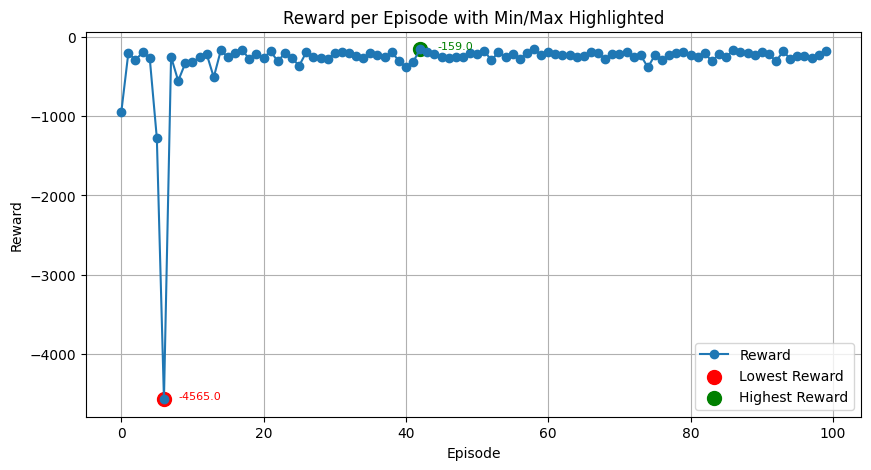

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load CSV
df = pd.read_csv("acrobot_train.csv")

# Find the episodes with min and max reward
min_idx = df["reward"].idxmin()
max_idx = df["reward"].idxmax()

# Plot reward per episode
plt.figure(figsize=(10, 5))
plt.plot(df["episode"], df["reward"], marker='o', linestyle='-', label="Reward")

# Highlight min and max
plt.scatter(df.loc[min_idx, "episode"], df.loc[min_idx, "reward"], color='red', s=100, label="Lowest Reward")
plt.scatter(df.loc[max_idx, "episode"], df.loc[max_idx, "reward"], color='green', s=100, label="Highest Reward")

# Annotate min and max values
plt.text(df.loc[min_idx+5, "episode"], df.loc[min_idx, "reward"] - 1,  # slightly below
         f'{df.loc[min_idx, "reward"]}', color='red', fontsize=8, ha='center')
plt.text(df.loc[max_idx+5, "episode"], df.loc[max_idx, "reward"] + 0.5,  # slightly above
         f'{df.loc[max_idx, "reward"]}', color='green', fontsize=8, ha='center')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode with Min/Max Highlighted")
plt.legend()
plt.grid(True)
plt.show()


### Evaluatie Loop

In [ ]:
# code in kort
# from stable_baselines3.common.evaluation import evaluate_policy

# env = gym.make("Acrobot-v1", render_mode="rgb_array_list")  # enable rendering for evaluation
# mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=2, render=True) # weer 100 episodes voor een eerlijke vergelijking

# print(f"Mean reward: {mean_reward} ± {std_reward}")

# code wat langer met meer controle
import gymnasium as gym
import numpy as np

env = gym.make("Acrobot-v1", render_mode="rgb_array_list")  # keep rendering
num_episodes = 100 # choose how many episodes you want
max_steps = 2015

all_rewards = []
all_lengths = []
all_actions = []

for ep in range(num_episodes):
    obs, _ = env.reset()
    terminated = False
    total_reward = 0
    step_count = 0
    episode_actions = []

    while not terminated or step_count >= max_steps:
        # predict action using trained model
        action, _ = model.predict(obs, deterministic=True)  # greedy evaluation
        episode_actions.append(int(action))  # log action

        # take a step in the env
        next_obs, reward, terminated, _, info = env.step(action)

        total_reward += reward
        obs = next_obs
        step_count += 1

    all_rewards.append(total_reward)
    all_lengths.append(step_count)
    all_actions.append(episode_actions)

    print(f"Episode {ep} | Reward: {total_reward} | Steps: {step_count}")
    print(f"Actions: {episode_actions[:20]} ...")  # show first 20 actions

mean_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")



Episode 0 | Reward: -319.0 | Steps: 320
Actions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1] ...
Episode 1 | Reward: -272.0 | Steps: 273
Actions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1] ...
Episode 2 | Reward: -307.0 | Steps: 308
Actions: [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0] ...
Episode 3 | Reward: -285.0 | Steps: 286
Actions: [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0] ...
Episode 4 | Reward: -245.0 | Steps: 246
Actions: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1] ...
Episode 5 | Reward: -343.0 | Steps: 344
Actions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1] ...
Episode 6 | Reward: -344.0 | Steps: 345
Actions: [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0] ...
Episode 7 | Reward: -253.0 | Steps: 254
Actions: [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0] ...
Episode 8 | Reward: -249.0 | Steps: 250
Actions: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,

### Data Omzetten in Dataframe

In [ ]:
import pandas as pd
import numpy as np

# Example: suppose you have this from your manual loop
all_rewards
num_episodes = len(all_rewards)

# Create a DataFrame
df = pd.DataFrame({
    "episode": np.arange(num_episodes),  # 0, 1, 2, ...
    "reward": all_rewards,
    "actions": all_actions
})

print(df)


    episode  reward                                            actions
0         0  -319.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1         1  -272.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2         2  -307.0  [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
3         3  -285.0  [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...
4         4  -245.0  [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, ...
..      ...     ...                                                ...
95       95  -247.0  [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...
96       96  -265.0  [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, ...
97       97  -302.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
98       98  -337.0  [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, ...
99       99  -286.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...

[100 rows x 3 columns]


### Evaluatie Plotten

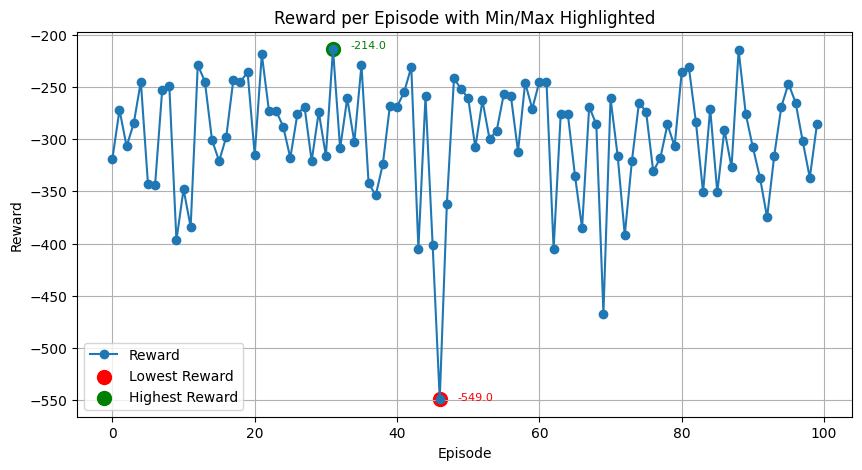

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Find the episodes with min and max reward
min_idx = df["reward"].idxmin()
max_idx = df["reward"].idxmax()

# Plot reward per episode
plt.figure(figsize=(10, 5))
plt.plot(df["episode"], df["reward"], marker='o', linestyle='-', label="Reward")

# Highlight min and max
plt.scatter(df.loc[min_idx, "episode"], df.loc[min_idx, "reward"], color='red', s=100, label="Lowest Reward")
plt.scatter(df.loc[max_idx, "episode"], df.loc[max_idx, "reward"], color='green', s=100, label="Highest Reward")

# Annotate min and max values
plt.text(df.loc[min_idx+5, "episode"], df.loc[min_idx, "reward"] - 1,  # slightly below
         f'{df.loc[min_idx, "reward"]}', color='red', fontsize=8, ha='center')
plt.text(df.loc[max_idx+5, "episode"], df.loc[max_idx, "reward"] + 0.5,  # slightly above
         f'{df.loc[max_idx, "reward"]}', color='green', fontsize=8, ha='center')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode with Min/Max Highlighted")
plt.legend()
plt.grid(True)
plt.show()

Doet mijn model het beter dan de baseline? Mijn model loste de slechtste episode op binnen 550 stappen en de beste binnen 214 stappen. Het baseline model haalde een gemiddelde score van -2015.3 over 100 episodes en mijn eerste model behaalt een gemiddelde score van -297.39 over 100 episodes. Ik kan dus concluderen dat mijn model de baseline model outperformt.

Ik zou nu kunnen stoppen, maar ik benoemde eerder dat in de documentatie staat dat een score van -100 gelijk staat aan het probleem succesvol oplossen. Daarom ga ik proberen om in de tweede iteratie het model zo goed mogelijk te maken.

## Iteratie 2

In de eerste iteratie heb ik getraind op 100 episodes. In iteratie 2 ga ik trainen over 250 episodes om zo te kijken of ik betere resultaten krijg.

### Model Init & Training Loop

In [ ]:
from stable_baselines3.common.logger import configure
import torch
from stable_baselines3 import DQN
import gymnasium as gym

# setup
env = gym.make("Acrobot-v1")  # enable rendering for evaluation

model = DQN(
    "MlpPolicy", # andere mogelijke policies zijn CnnPolicy en MultiInputPolicy maar die zijn niet geschikt voor deze omgeving omdat we geen Cnn gebruiken en geen multi input hebben
    env,
    device="cuda"
)
logger = configure(folder="./logs/", format_strings=["stdout"])  
model.set_logger(logger)

# code training loop - kort
# model.learn(total_timesteps=100000) # ja maar 1 regel 💔

# code training loop - lang met meer controle
num_episodes = 250
max_steps_per_episode = 5000


episode_rewards = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    total_reward = 0
    terminated = False

    while not terminated:
        # Take action (with exploration)
        action, _ = model.predict(obs)

        next_obs, reward, terminated, _, _ = env.step(action) # geen truncation want ik wil max steps zelf bepalen

        # Store transition
        model.replay_buffer.add(obs, next_obs, action, reward, terminated, [{}])

        obs = next_obs
        total_reward += reward

        # Train
        if model.num_timesteps > model.learning_starts:
            model.train(batch_size=model.batch_size, gradient_steps=1)

        model.num_timesteps += 1  # IMPORTANT: SB3 uses this internally

        if terminated:
            break

    episode_rewards.append(total_reward)
    print(f"Episode {episode} | Reward: {total_reward}")


Episode 0 | Reward: -367.0
Episode 1 | Reward: -467.0
Episode 2 | Reward: -287.0
Episode 3 | Reward: -238.0
Episode 4 | Reward: -223.0
Episode 5 | Reward: -192.0
Episode 6 | Reward: -165.0
Episode 7 | Reward: -307.0
Episode 8 | Reward: -338.0
Episode 9 | Reward: -289.0
Episode 10 | Reward: -228.0
Episode 11 | Reward: -290.0
Episode 12 | Reward: -204.0
Episode 13 | Reward: -272.0
Episode 14 | Reward: -350.0
Episode 15 | Reward: -452.0
Episode 16 | Reward: -306.0
Episode 17 | Reward: -184.0
Episode 18 | Reward: -205.0
Episode 19 | Reward: -124.0
Episode 20 | Reward: -280.0
Episode 21 | Reward: -234.0
Episode 22 | Reward: -118.0
Episode 23 | Reward: -122.0
Episode 24 | Reward: -347.0
Episode 25 | Reward: -134.0
Episode 26 | Reward: -167.0
Episode 27 | Reward: -124.0
Episode 28 | Reward: -172.0
Episode 29 | Reward: -291.0
Episode 30 | Reward: -136.0
Episode 31 | Reward: -108.0
Episode 32 | Reward: -132.0
Episode 33 | Reward: -183.0
Episode 34 | Reward: -154.0
Episode 35 | Reward: -113.0
Ep

### Training Plotten

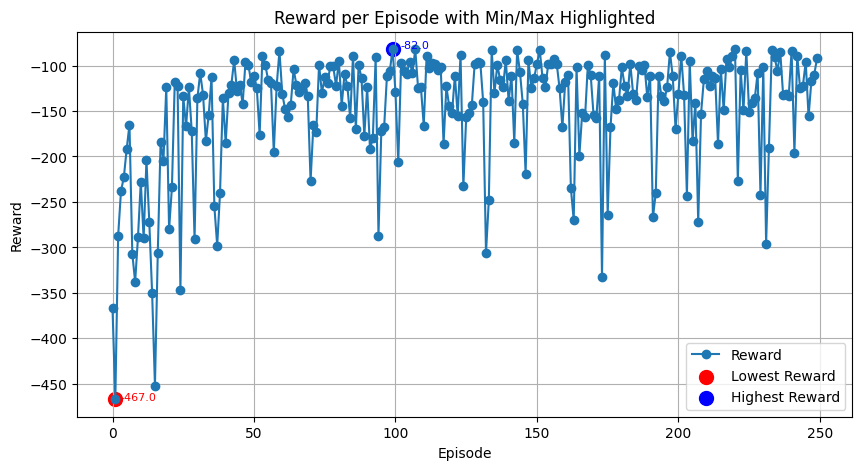

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Load CSV
df = pd.read_csv("acrobot_train_it2.csv")

# Find the episodes with min and max reward
min_idx = df["reward"].idxmin()
max_idx = df["reward"].idxmax()

# Plot reward per episode
plt.figure(figsize=(10, 5))
plt.plot(df["episode"], df["reward"], marker='o', linestyle='-', label="Reward")

# Highlight min and max
plt.scatter(df.loc[min_idx, "episode"], df.loc[min_idx, "reward"], color='red', s=100, label="Lowest Reward")
plt.scatter(df.loc[max_idx, "episode"], df.loc[max_idx, "reward"], color='blue', s=100, label="Highest Reward")

# Annotate min and max values
plt.text(df.loc[min_idx+8, "episode"], df.loc[min_idx, "reward"] - 1,  # slightly below
         f'{df.loc[min_idx, "reward"]}', color='red', fontsize=8, ha='center')
plt.text(df.loc[max_idx+8, "episode"], df.loc[max_idx, "reward"] + 0.5,  # slightly above
         f'{df.loc[max_idx, "reward"]}', color='blue', fontsize=8, ha='center')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode with Min/Max Highlighted")
plt.legend()
plt.grid(True)
plt.show()


### Evaluatie Loop

In [ ]:
# code in kort
# from stable_baselines3.common.evaluation import evaluate_policy

# env = gym.make("Acrobot-v1", render_mode="rgb_array_list")  # enable rendering for evaluation
# mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=2, render=True) # weer 100 episodes voor een eerlijke vergelijking

# print(f"Mean reward: {mean_reward} ± {std_reward}")

# code wat langer met meer controle
import gymnasium as gym
import numpy as np

env = gym.make("Acrobot-v1")  # keep rendering
num_episodes = 100 # choose how many episodes you want
max_steps = 2015

all_rewards = []
all_lengths = []
all_actions = []

for ep in range(num_episodes):
    obs, _ = env.reset()
    terminated = False
    total_reward = 0
    step_count = 0
    episode_actions = []
    frames = [] # store last episode for gif

    while not terminated or step_count >= max_steps:
        frame = env.render()
        frames.append(frame)
        
        # predict action using trained model
        action, _ = model.predict(obs, deterministic=True)  # greedy evaluation
        episode_actions.append(int(action))  # log action

        # take a step in the env
        next_obs, reward, terminated, _, info = env.step(action)

        total_reward += reward
        obs = next_obs
        step_count += 1

    all_rewards.append(total_reward)
    all_lengths.append(step_count)
    all_actions.append(episode_actions)

    print(f"Episode {ep} | Reward: {total_reward} | Steps: {step_count}")
    print(f"Actions: {episode_actions[:20]} ...")  # show first 20 actions

mean_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")



Episode 0 | Reward: -341.0 | Steps: 342
Actions: [0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2] ...
Episode 1 | Reward: -72.0 | Steps: 73
Actions: [0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2] ...
Episode 2 | Reward: -758.0 | Steps: 759
Actions: [0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2] ...
Episode 3 | Reward: -100.0 | Steps: 101
Actions: [2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0] ...
Episode 4 | Reward: -91.0 | Steps: 92
Actions: [0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2] ...
Episode 5 | Reward: -107.0 | Steps: 108
Actions: [0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2] ...
Episode 6 | Reward: -105.0 | Steps: 106
Actions: [0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2] ...
Episode 7 | Reward: -167.0 | Steps: 168
Actions: [0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2] ...
Episode 8 | Reward: -212.0 | Steps: 213
Actions: [2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 

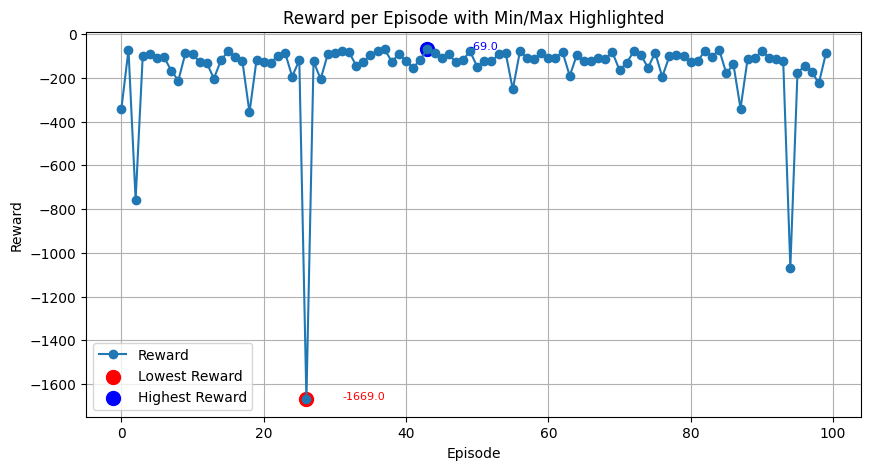

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Load CSV
df = pd.read_csv("acrobot_train_it2_e.csv")

# Find the episodes with min and max reward
min_idx = df["reward"].idxmin()
max_idx = df["reward"].idxmax()

# Plot reward per episode
plt.figure(figsize=(10, 5))
plt.plot(df["episode"], df["reward"], marker='o', linestyle='-', label="Reward")

# Highlight min and max
plt.scatter(df.loc[min_idx, "episode"], df.loc[min_idx, "reward"], color='red', s=100, label="Lowest Reward")
plt.scatter(df.loc[max_idx, "episode"], df.loc[max_idx, "reward"], color='blue', s=100, label="Highest Reward")

# Annotate min and max values
plt.text(df.loc[min_idx+8, "episode"], df.loc[min_idx, "reward"] - 1,  # slightly below
         f'{df.loc[min_idx, "reward"]}', color='red', fontsize=8, ha='center')
plt.text(df.loc[max_idx+8, "episode"], df.loc[max_idx, "reward"] + 0.5,  # slightly above
         f'{df.loc[max_idx, "reward"]}', color='blue', fontsize=8, ha='center')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode with Min/Max Highlighted")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
g = np.array(frames)
g = np.squeeze(g)  # remove any extra dimensions if needed
g.shape

(3, 500, 500, 3)

In [ ]:
import imageio
imageio.mimsave("episode_89.gif", g, fps=60)

Dit is de laatste episode uit mijn evaluatie. Deze episode wordt uitgespeeld in 89 stappen. Als het filmpje niet afspeelt kun je hem nog bekijken op DLO. Ik heb hem daar ingeleverd. of klik [hier](https://raw.githubusercontent.com/School-Semester-Summaries/MAAI-S2/refs/heads/main/M%26T/3b/episode_89.gif) voor de video link.

![image](https://raw.githubusercontent.com/School-Semester-Summaries/MAAI-S2/refs/heads/main/M%26T/3b/episode_89.gif)

Ik heb mijn model iets beter gekregen. De gemiddelde score is in iteratie 2 -156,18. Helaas niet onder de -100 maar wel beter dan de baseline.

Als er een 3de iteratie zou zijn zou ik toch een on-policy algoritme uitproberen. Voornamelijk uit niewsgierigheid hoe goed een on-policy algoritme zou performen ten opzichte van een off-policy algoritme in dit gegeven scenario. Ook heb ik tijdens dit experiment begrepen hoe instabiel DQN is. Soms train ik voor 100 episodes en heb ik een super goed model en soms train ik 100 episodes en heb ik letterlijk niks. hetzelfde princiepe geldt voor 200, 250, 500 episodes. Ik weet 100% zeker dat als ik mijn model meerdere keren opnieuw zou trainen het vast wel ooit onder een gemiddelde score van -100 komt maar misschien is het stabielier om dit te bereiken met een on-policy algoritme.